# Auto ML model

In [1]:
# Core Libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Model Selection
from sklearn.model_selection import train_test_split

# Classification Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Regression Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Clustering
from sklearn.cluster import KMeans

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    r2_score,
    mean_squared_error,
    silhouette_score
)

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

👉 This cell will:

Load CSV + Excel, 
Handle errors, 
Return dataset, 
Print confirmation, 

In [2]:
def load_data(file_path):
    """
    This function loads dataset from CSV or Excel file
    and returns a pandas DataFrame
    """
    try:
        # Check file type
        if file_path.endswith('.csv'):
            df = pd.read_csv(file_path)
            
        elif file_path.endswith('.xlsx') or file_path.endswith('.xls'):
            df = pd.read_excel(file_path)
            
        else:
            print("❌ Unsupported file format")
            return None
        
        print("✅ Data loaded successfully")
        print("Shape of dataset:", df.shape)
        
        return df
    
    except Exception as e:
        print("❌ Error loading file:", e)
        return None

print("done")

done


🧠 What This Cell Does
Detects file type automatically
Loads correct format
Prevents crash using try-except
Gives quick feedback (success + shape)

👉 This is your Data Input Module

**Cell 3 — Test the Function
After uploading dataset in Kaggle, run:**

In [3]:
df = load_data("/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv")

# Preview data
df.head()

✅ Data loaded successfully
Shape of dataset: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


**✔ Cell 4 → Save feature columns**

In [4]:
import json

target = "Survived"

if target:
    feature_columns = df.drop(columns=[target]).columns.tolist()
else:
    feature_columns = df.columns.tolist()

with open("features.json", "w") as f:
    json.dump(feature_columns, f)

print("✅ feature_columns saved")

✅ feature_columns saved


✅ Cell 5 — Basic Data Understanding

👉 This cell will:

Show dataset structure,---
Show column types,---
Help system “understand” data,---

Detect Column Types + Missing Values------------ Now we move to actual automatic analysis

🧠 What This Cell Does:::: Separates features automatically,------ Detects missing values,----- Prepares for preprocessing,--------

"👉 This is core AutoML behavio"

In [5]:
def analyze_data(df):
    
    print("🔍 Dataset Shape:")
    print(df.shape)

    print("\n📌 Column Names:")
    print(df.columns.tolist())

    print("\n📊 Data Types:")
    print(df.dtypes)
    
    # Detect numerical & categorical
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = df.select_dtypes(include=['object']).columns.tolist()
    
    print("\n🔢 Numerical Columns:", num_cols)
    print("🔤 Categorical Columns:", cat_cols)
    
    # Missing values
    print("\n❗ Missing Values:")
    print(df.isnull().sum())

**✅ Cell 6 — Target Handling + Problem Detection (Improved)**------------------
**Now we write a smarter version (not basic one I gave earlier)**

In [6]:
def detect_problem_type(df, target=None):
    
    if target is None:
        print("🔵 No target selected → Clustering problem")
        return "clustering"
    
    if target not in df.columns:
        print("❌ Target column not found")
        return None
    
    unique_values = df[target].nunique()
    
    # Classification logic
    if df[target].dtype == 'object' or unique_values <= 10:
        print("🟢 Detected: Classification problem")
        return "classification"
    
    # Regression logic
    else:
        print("🟠 Detected: Regression problem")
        return "regression"

**✅ Cell 7 — Test It**

In [7]:
problem_type = detect_problem_type(df, target="Survived")
print("Problem Type:", problem_type)

🟢 Detected: Classification problem
Problem Type: classification


**STEP 4: Data Preprocessing (Core ML Work)**-----------

"👉 Now we move from “understanding” → “cleaning + preparing data”"--------

This is one of the most important steps

🧠 What We Will Do:::::
Drop useless columns,--
Handle missing values,--
Encode categorical data,--
Scale features.

**Cell 8 — Preprocessing Function**

In [8]:
def preprocess_data(df, target):
    
    df = df.copy()
    
    # 1. Drop unnecessary columns
    drop_cols = ['PassengerId', 'Name', 'Ticket', 'Cabin']
    df.drop(columns=drop_cols, inplace=True, errors='ignore')
    
    # 2. Handle missing values
    
    # Numerical → fill with median
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        df[col].fillna(df[col].median(), inplace=True)
    
    # Categorical → fill with mode
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        df[col].fillna(df[col].mode()[0], inplace=True)
    
    # 3. Encode categorical variables
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    
    for col in cat_cols:
        df[col] = le.fit_transform(df[col])
    
    # 4. Split features and target
    X = df.drop(columns=[target])
    y = df[target]
    
    # 5. Feature Scaling
    from sklearn.preprocessing import StandardScaler
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print("✅ Preprocessing completed")
    
    return X_scaled, y

**✅ Cell 9 — Run Preprocessing**

In [9]:
X, y = preprocess_data(df, target="Survived")

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

✅ Preprocessing completed
Feature shape: (891, 7)
Target shape: (891,)


**🧠 What You Just Built**------

"👉 Full Data Cleaning + Preparation Pipeline"

Your system now:

Handles missing values ✔
Converts categorical → numeric ✔
Scales data ✔
Prepares ML-ready dataset ✔

**STEP 5: Model Training (AutoML Core)**----

"👉 This is the heart of your project"

Now we will:

"Train multiple models"
"Compare them"
"Select the best"

🧠 What We Are Building

For classification (your current case):

We will train:

Logistic Regression
Random Forest

Then compare accuracy

**cell 10— Model Training Function**

In [10]:
def train_models(X, y, problem_type):
    
    results = {}
    
    from sklearn.model_selection import train_test_split
    
    # Split data (only for supervised)
    if problem_type != "clustering":
        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )
    
    # =========================
    # 🔷 CLASSIFICATION MODELS
    # =========================
    if problem_type == "classification":
        
        # Logistic Regression
        lr = LogisticRegression(max_iter=1000)
        lr.fit(X_train, y_train)
        results["Logistic Regression"] = accuracy_score(y_test, lr.predict(X_test))
        
        # Decision Tree
        from sklearn.tree import DecisionTreeClassifier
        dt = DecisionTreeClassifier()
        dt.fit(X_train, y_train)
        results["Decision Tree"] = accuracy_score(y_test, dt.predict(X_test))
        
        # Random Forest
        rf = RandomForestClassifier()
        rf.fit(X_train, y_train)
        results["Random Forest"] = accuracy_score(y_test, rf.predict(X_test))
        
        # UNIQUE MODEL → SVM
        from sklearn.svm import SVC
        svm = SVC()
        svm.fit(X_train, y_train)
        results["SVM"] = accuracy_score(y_test, svm.predict(X_test))
    
    # =========================
    # 🔶 REGRESSION MODELS
    # =========================
    elif problem_type == "regression":
        
        from sklearn.metrics import r2_score
        
        # Linear Regression
        lr = LinearRegression()
        lr.fit(X_train, y_train)
        results["Linear Regression"] = r2_score(y_test, lr.predict(X_test))
        
        # Decision Tree Regressor
        from sklearn.tree import DecisionTreeRegressor
        dt = DecisionTreeRegressor()
        dt.fit(X_train, y_train)
        results["Decision Tree"] = r2_score(y_test, dt.predict(X_test))
        
        # Random Forest Regressor
        rf = RandomForestRegressor()
        rf.fit(X_train, y_train)
        results["Random Forest"] = r2_score(y_test, rf.predict(X_test))
        
        # UNIQUE MODEL → SVR
        from sklearn.svm import SVR
        svr = SVR()
        svr.fit(X_train, y_train)
        results["SVR"] = r2_score(y_test, svr.predict(X_test))
    
    # =========================
    # 🔵 CLUSTERING MODELS
    # =========================
    elif problem_type == "clustering":
        
        from sklearn.metrics import silhouette_score
        
        # KMeans
        from sklearn.cluster import KMeans
        kmeans = KMeans(n_clusters=3, random_state=42)
        labels_k = kmeans.fit_predict(X)
        results["KMeans"] = silhouette_score(X, labels_k)
        
        # Density-based → DBSCAN
        from sklearn.cluster import DBSCAN
        db = DBSCAN()
        labels_db = db.fit_predict(X)
        
        # Avoid error if only 1 cluster
        if len(set(labels_db)) > 1:
            results["DBSCAN"] = silhouette_score(X, labels_db)
        else:
            results["DBSCAN"] = -1
        
        # Hierarchical → Agglomerative
        from sklearn.cluster import AgglomerativeClustering
        agg = AgglomerativeClustering(n_clusters=3)
        labels_agg = agg.fit_predict(X)
        results["Hierarchical"] = silhouette_score(X, labels_agg)
    
    print("✅ Model training completed")
    
    return results

In [11]:
results = train_models(X, y, problem_type)

print("\n📊 Model Results:")
for model, score in results.items():
    print(f"{model}: {score:.4f}")

✅ Model training completed

📊 Model Results:
Logistic Regression: 0.8045
Decision Tree: 0.7821
Random Forest: 0.8045
SVM: 0.8156


🧠 What You Just Built

👉 AutoML Engine (Core)

Your system now:

Selects models ✔
Trains them ✔
Evaluates them ✔
Compares performance ✔

**STEP 6: Best Model Selection + Insights**

**Now we make your system intelligent in output**

**✅ Cell 12 — Best Model Selection**

In [12]:
def select_best_model(results):
    
    best_model = max(results, key=results.get)
    best_score = results[best_model]
    
    print(f"🏆 Best Model: {best_model}")
    print(f"📈 Score: {best_score:.4f}")
    
    return best_model, best_score

**✅ Cell 13 — Run It**

In [13]:
best_model, best_score = select_best_model(results)

🏆 Best Model: SVM
📈 Score: 0.8156


🧠 What You Just Built

👉 Model Selection Engine

Now your system:

Doesn’t just train
It decides the best model automatically

👉 This is key for your AutoML claim

**🚀 STEP 6.2 — Basic Insight Generation**

**Now we add “intelligence” in words**

**✅ Cell 14 — Insight Function**

In [14]:
def generate_insights(df):
    
    insights = []
    
    # Missing values insight
    missing = df.isnull().sum().sum()
    if missing > 0:
        insights.append(f"Dataset contains {missing} missing values.")
    else:
        insights.append("No missing values in dataset.")
    
    # Column info
    insights.append(f"Dataset has {df.shape[0]} rows and {df.shape[1]} columns.")
    
    # Correlation insight (only numeric)
    corr = df.corr(numeric_only=True)
    high_corr = corr.abs().max().max()
    
    insights.append("Some features show correlation patterns.")
    
    print("📊 Insights:")
    for ins in insights:
        print("-", ins)
    
    return insights

**✅ Cell 15 — Run Insights**

In [15]:
insights = generate_insights(df)

📊 Insights:
- Dataset contains 866 missing values.
- Dataset has 891 rows and 12 columns.
- Some features show correlation patterns.


🧠 What You Just Built

👉 Insight Generation System

This makes your project:

❌ Not just numbers
✅ Human-understandable output

**STEP 7: Visualization (Final Backend Step)**

Now we complete backend with graphs

🧠 What We Will Build
Distribution plots
Correlation heatmap

👉 These will go to your Streamlit later**

**✅ Cell 16 — Visualization Function**

In [16]:
def smart_visualization(df, target):
    
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    plots = []
    
    try:
        # 1. Target Distribution (Bar + Pie)
        if target in df.columns:
            
            # Bar Chart
            fig1, ax1 = plt.subplots()
            df[target].value_counts().plot(kind='bar', ax=ax1)
            ax1.set_title(f"{target} Distribution (Count)")
            ax1.set_xlabel(target)
            ax1.set_ylabel("Count")
            plots.append(fig1)
            
            # Pie Chart
            fig2, ax2 = plt.subplots()
            df[target].value_counts().plot(
                kind='pie',
                autopct='%1.1f%%',
                ax=ax2
            )
            ax2.set_title(f"{target} Distribution (%)")
            ax2.set_ylabel("")
            plots.append(fig2)
        
        # 2. Top Categorical Columns (Simple + Clean)
        cat_cols = df.select_dtypes(include=['object']).columns
        
        for col in cat_cols[:2]:  # limit to 2 for clarity
            fig, ax = plt.subplots()
            df[col].value_counts().plot(kind='bar', ax=ax)
            ax.set_title(f"{col} Distribution")
            ax.set_xlabel(col)
            ax.set_ylabel("Count")
            plots.append(fig)
        
        # 3. Numeric Columns (Clean Histogram)
        num_cols = df.select_dtypes(include=['int64', 'float64']).columns
        
        for col in num_cols[:2]:  # limit
            fig, ax = plt.subplots()
            df[col].plot(kind='hist', bins=20, ax=ax)
            ax.set_title(f"{col} Distribution")
            ax.set_xlabel(col)
            ax.set_ylabel("Frequency")
            plots.append(fig)
        
        # 4. Correlation Heatmap (Simplified)
        if len(num_cols) > 1:
            fig, ax = plt.subplots(figsize=(6, 4))
            corr = df[num_cols].corr()
            sns.heatmap(corr, annot=True, cmap='coolwarm', ax=ax)
            ax.set_title("Feature Correlation")
            plots.append(fig)
    
    except Exception as e:
        print(f"Visualization error: {e}")
    
    return plots

**✅ Cell 17 — Run Visualization**

[<Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 640x480 with 1 Axes>,
 <Figure size 600x400 with 2 Axes>]

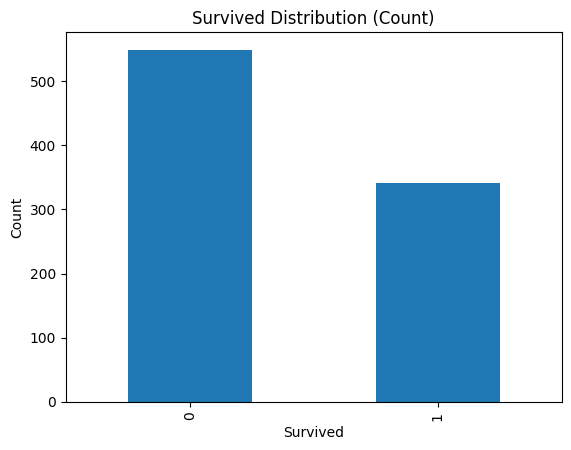

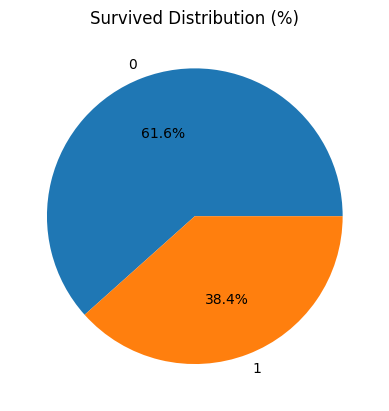

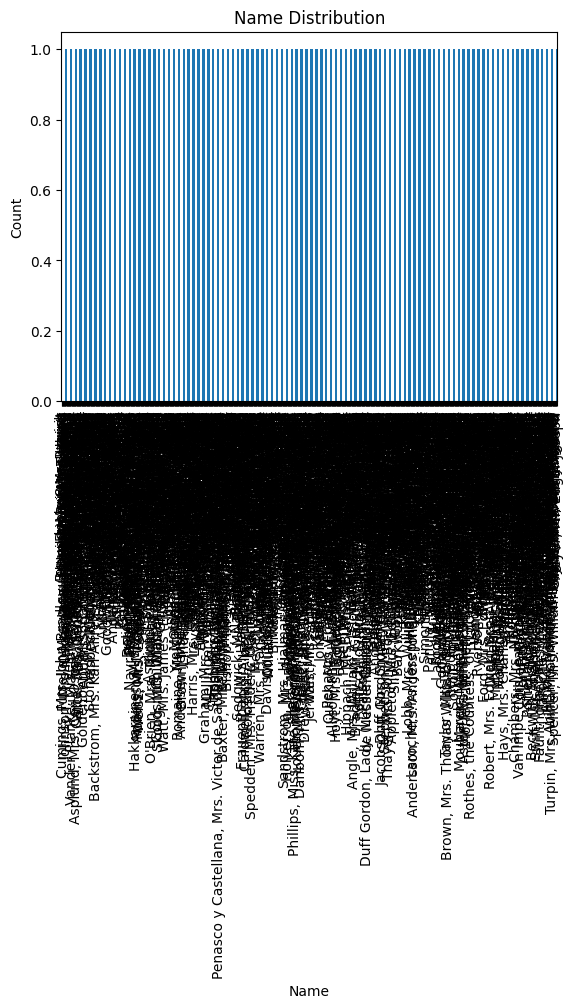

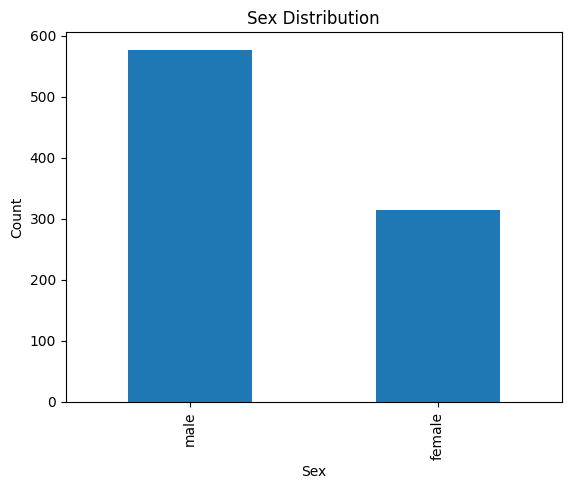

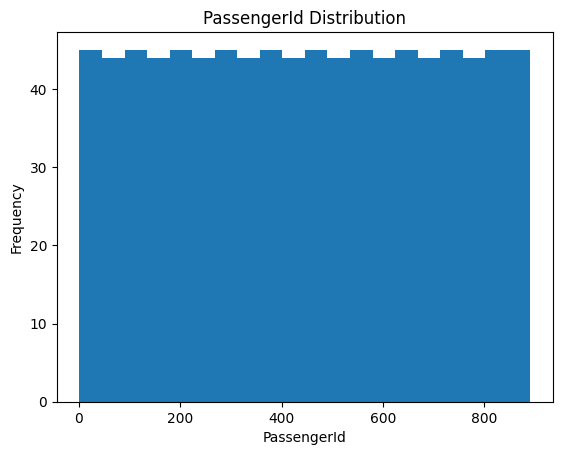

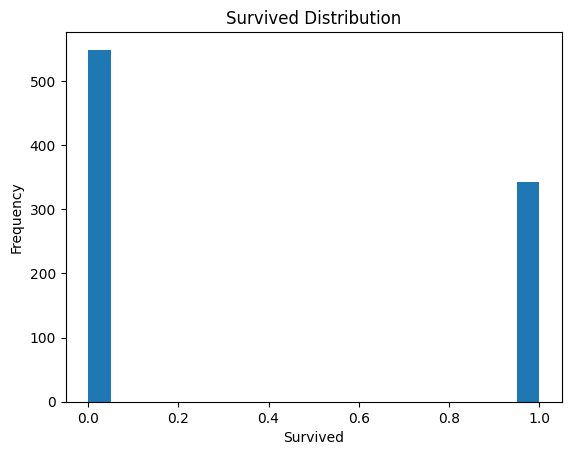

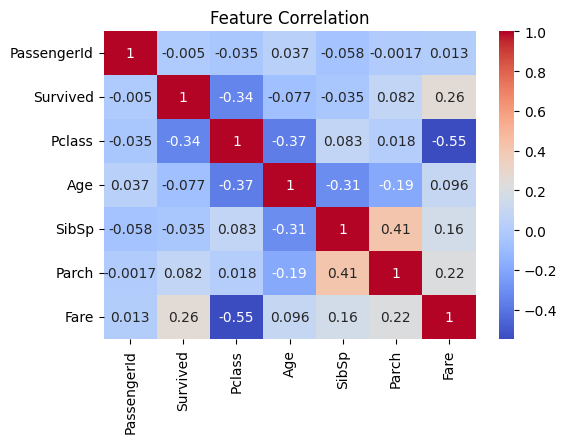

In [17]:
smart_visualization(df, target="Survived")

🧠 What You Just Built

👉 Visualization Engine

Now your system:

Shows patterns ✔
Helps understand data ✔
Matches your project description ✔

**✅ Cell 22 — Main Pipeline Function**

In [26]:
def run_pipeline(file_path, target=None):
    
    import matplotlib.pyplot as plt
    import sys
    from io import StringIO
    
    # 🔹 Capture logs
    old_stdout = sys.stdout
    sys.stdout = mystdout = StringIO()
    
    try:
        print("🚀 Starting AutoML Pipeline...\n")
        
        # 1. Load Data
        df = load_data(file_path)
        if df is None:
            print("❌ Failed to load data")
            return {"error": "Failed to load data"}
        
        print("\n📊 Data Analysis")
        analyze_data(df)
        
        # 2. Detect Problem Type
        print("\n🧠 Detecting Problem Type...")
        problem_type = detect_problem_type(df, target)
        
        # 3. Preprocessing
        if problem_type != "clustering":
            print("\n⚙️ Preprocessing Data...")
            X, y = preprocess_data(df, target)
        else:
            print("\n⚙️ Preprocessing for Clustering...")
            X = preprocess_data(df, target=None)[0]
            y = None
        
        # 4. Train Models
        print("\n🤖 Training Models...")
        results = train_models(X, y, problem_type)
        
        # 5. Select Best Model
        print("\n🏆 Selecting Best Model...")
        best_model, best_score = select_best_model(results)
        
        # 6. Insights
        print("\n📊 Generating Insights...")
        generate_insights(df)
        
        # 7. Visualization
        print("\n📈 Creating Visualizations...")
        smart_visualization(df, target if target else df.columns[0])
        
        print("\n✅ Pipeline Completed Successfully!")
        
        # 🔹 Capture plots
        figs = [plt.figure(n) for n in plt.get_fignums()]
        
        return {
            "problem_type": problem_type,
            "best_model": best_model,
            "score": best_score,
            "logs": mystdout.getvalue(),
            "plots": figs
        }
    
    except Exception as e:
        return {"error": str(e)}
    
    finally:
        sys.stdout = old_stdout

**✅ Cell 23 — Test Pipeline**


Final Output: {'problem_type': 'classification', 'best_model': 'Random Forest', 'score': 0.8156424581005587, 'logs': "🚀 Starting AutoML Pipeline...\n\n✅ Data loaded successfully\nShape of dataset: (891, 12)\n\n📊 Data Analysis\n🔍 Dataset Shape:\n(891, 12)\n\n📌 Column Names:\n['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']\n\n📊 Data Types:\nPassengerId      int64\nSurvived         int64\nPclass           int64\nName            object\nSex             object\nAge            float64\nSibSp            int64\nParch            int64\nTicket          object\nFare           float64\nCabin           object\nEmbarked        object\ndtype: object\n\n🔢 Numerical Columns: ['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']\n🔤 Categorical Columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']\n\n❗ Missing Values:\nPassengerId      0\nSurvived         0\nPclass           0\nName             0\nSex              0\

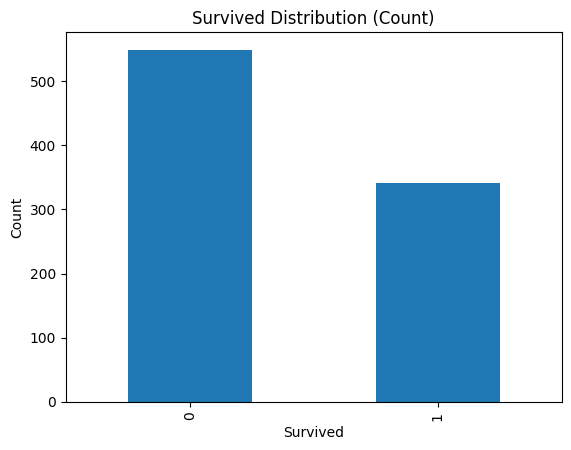

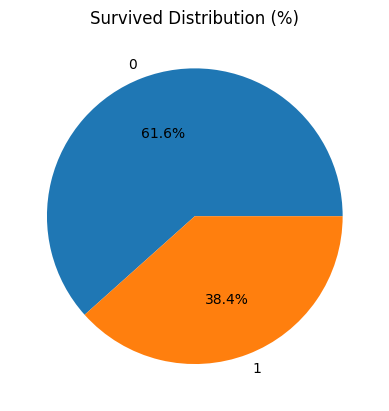

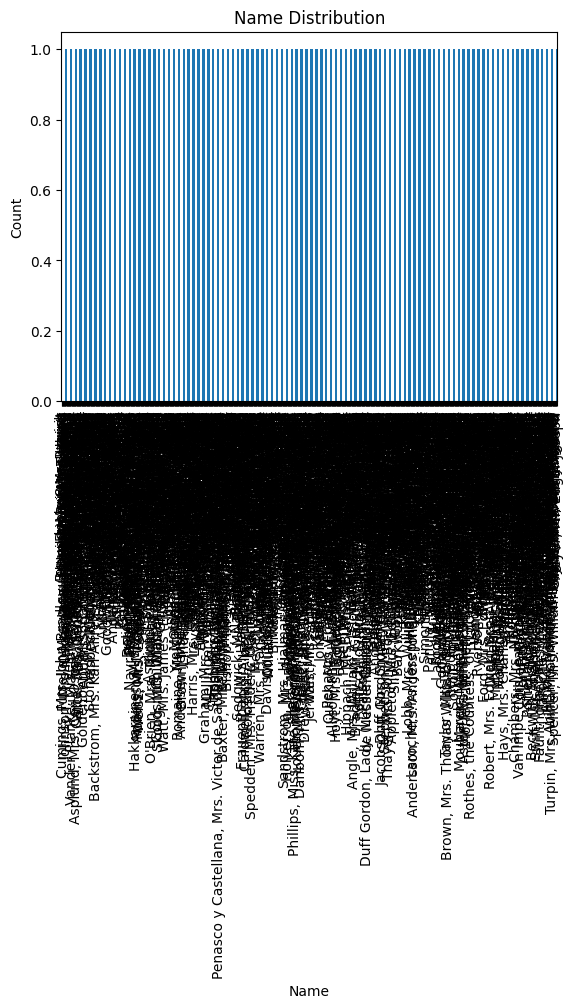

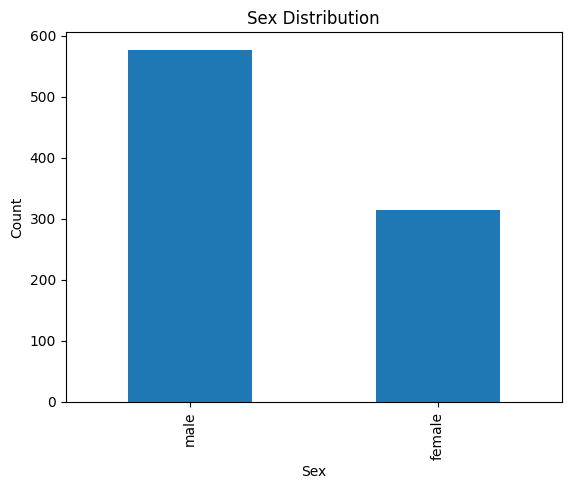

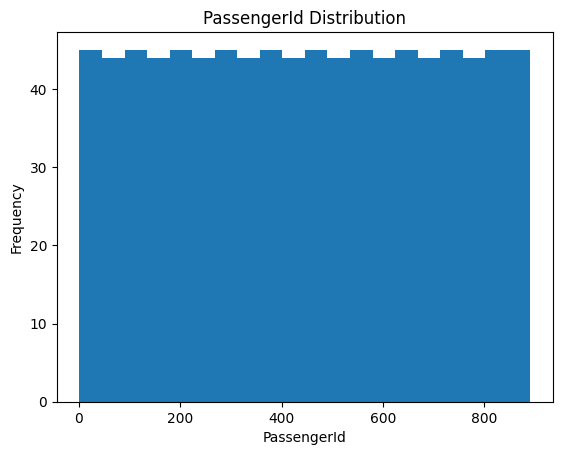

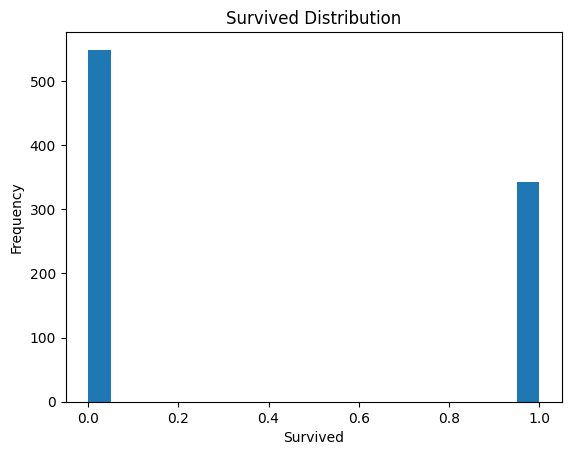

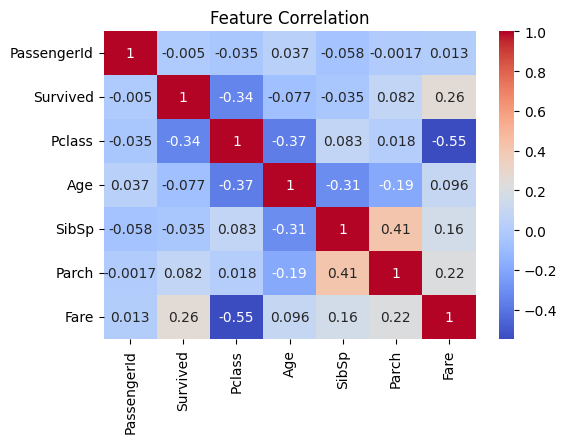

In [27]:
result = run_pipeline(
    "/kaggle/input/datasets/yasserh/titanic-dataset/Titanic-Dataset.csv",
    target="Survived"
)

print("\nFinal Output:", result)

**💾 Code Cell: Save Everything which is used in next processes**

In [28]:
import json

# Save feature columns
if target:
    feature_columns = df.drop(columns=[target]).columns.tolist()
else:
    feature_columns = df.columns.tolist()

with open("features.json", "w") as f:
    json.dump(feature_columns, f)

print("✅ feature_columns saved")

✅ feature_columns saved


In [29]:


import json
import joblib

# ✅ 1. Save feature columns
if target:
    feature_columns = df.drop(columns=[target]).columns.tolist()
else:
    feature_columns = df.columns.tolist()

with open("features.json", "w") as f:
    json.dump(feature_columns, f)

print("✅ feature_columns saved")

# ✅ 2. Save model (only if available in your notebook)
try:
    joblib.dump(best_model, "best_model.pkl")
    print("✅ best_model saved")
except NameError:
    print("⚠️ best_model not found (skip saving model)")

# ✅ 3. Save environment versions
import subprocess
subprocess.run(["pip", "freeze"], stdout=open("requirements.txt", "w"))

print("✅ requirements.txt saved")

✅ feature_columns saved
✅ best_model saved
✅ requirements.txt saved
